# 🎯 FIUS Ultrasonic Sensor — Feature Engineering + Model Training
## Goal: Achieve >95% accuracy classifying Human vs Chair vs Nothing
---
**What this notebook does:**
1. Loads data (same as Data_Exploration)
2. Extracts smart features from the 25,000-sample echo signals
3. Splits into Train/Test sets
4. Trains multiple ML models (Random Forest, XGBoost, SVM, etc.)
5. Evaluates and compares all models
6. Shows detailed results for the best model

## Cell 1 — Setup & Imports

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install XGBoost and LightGBM (if not already)
!pip install -q xgboost lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gc
import csv
import os
import warnings
import pickle

from scipy import stats as sp_stats
from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
print('✅ All libraries loaded!')

Mounted at /content/drive
✅ All libraries loaded!


## Cell 2 — File Paths

In [ ]:
# ⚠️  UPDATE THESE PATHS — same as Step 1
BASE_DIR = '/content/drive/MyDrive/VER Machine Learning Data'

FILE_PATHS = {
    'human':   os.path.join(BASE_DIR, 'signal_human2.csv'),
    'chair':   os.path.join(BASE_DIR, 'signal_chair2.csv'),
    'nothing': os.path.join(BASE_DIR, 'signal_nothing.csv'),
}

# Verify
for label, path in FILE_PATHS.items():
    exists = os.path.exists(path)
    status = '✅' if exists else '❌ NOT FOUND'
    print(f'  {label:8s}: {status}  →  {path}')

  human   : ✅  →  /content/drive/MyDrive/VER Machine Learning Data/signal_human2.csv
  chair   : ✅  →  /content/drive/MyDrive/VER Machine Learning Data/signal_chair2.csv
  nothing : ✅  →  /content/drive/MyDrive/VER Machine Learning Data/signal_nothing.csv


## Cell 3 — Load Data (Memory-Efficient)

In [ ]:
N_METADATA_COLS = 17
N_SIGNAL_SAMPLES = 25000
SAMPLING_RATE = 1_953_125

def count_rows(filepath):
    with open(filepath, 'r') as f:
        return sum(1 for _ in f)

def load_csv_efficient(filepath, label, dtype=np.float32):
    print(f'  Counting rows...', end=' ')
    n_rows = count_rows(filepath)
    print(f'{n_rows} rows found.')
    metadata = np.empty((n_rows, N_METADATA_COLS), dtype=dtype)
    signal = np.empty((n_rows, N_SIGNAL_SAMPLES), dtype=dtype)
    print(f'  Loading...', end=' ')
    chunk_size = 100
    row_idx = 0
    with open(filepath, 'r') as f:
        reader = csv.reader(f)
        batch_rows = []
        for i, row in enumerate(reader):
            batch_rows.append(row)
            if len(batch_rows) == chunk_size:
                arr = np.array(batch_rows, dtype=dtype)
                n = arr.shape[0]
                metadata[row_idx:row_idx+n, :] = arr[:, :N_METADATA_COLS]
                signal[row_idx:row_idx+n, :] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
                row_idx += n
                batch_rows = []
                if row_idx % 1000 == 0:
                    print(f'{row_idx}..', end=' ')
        if batch_rows:
            arr = np.array(batch_rows, dtype=dtype)
            n = arr.shape[0]
            metadata[row_idx:row_idx+n, :] = arr[:, :N_METADATA_COLS]
            signal[row_idx:row_idx+n, :] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
            row_idx += n
    metadata = metadata[:row_idx]
    signal = signal[:row_idx]
    print(f'Done! {row_idx} rows loaded.')
    return metadata, signal

data = {}
for label, path in FILE_PATHS.items():
    print(f'\n📂 Loading {label.upper()}')
    t0 = time.time()
    meta, sig = load_csv_efficient(path, label)
    data[label] = {'metadata': meta, 'signal': sig}
    print(f'  ✅ Shape: {sig.shape} | Time: {time.time()-t0:.1f}s')
    gc.collect()

print(f'\n✅ All data loaded!')


📂 Loading HUMAN
  Counting rows... 5005 rows found.
  Loading... 1000.. 2000.. 3000.. 4000.. 5000.. Done! 5005 rows loaded.
  ✅ Shape: (5005, 25000) | Time: 59.7s

📂 Loading CHAIR
  Counting rows... 5000 rows found.
  Loading... 1000.. 2000.. 3000.. 4000.. 5000.. Done! 5000 rows loaded.
  ✅ Shape: (5000, 25000) | Time: 60.4s

📂 Loading NOTHING
  Counting rows... 5002 rows found.
  Loading... 1000.. 2000.. 3000.. 4000.. 5000.. Done! 5002 rows loaded.
  ✅ Shape: (5002, 25000) | Time: 59.5s

✅ All data loaded!


## Cell 4 — Feature Engineering 🧠
Extracting smart features from each 25,000-sample echo signal.

Based on Data_Exploration analysis, extract:
- **Segmented energy** (25 windows) — most discriminating feature from Data_Exploration
- **Global statistics** (RMS, peak, std, etc.)
- **Peak/echo location features** (WHERE the echo arrives)
- **Metadata features** (distance, energy metric)
- **Frequency domain** (spectral features)

In [ ]:
def extract_features(signal, metadata):
    """
    Extract features from one signal (1D array of 25000 values)
    and its metadata (1D array of 17 values).
    Returns a 1D feature vector.
    """
    features = {}

    # =============================================
    # 1. SEGMENTED ENERGY (25 windows of 1000 samples)
    #    This captures WHERE in time the echo energy is
    # =============================================
    N_WINDOWS = 25
    WINDOW_SIZE = 1000
    sig_windowed = signal[:N_WINDOWS * WINDOW_SIZE].reshape(N_WINDOWS, WINDOW_SIZE)
    seg_energy = np.sum(sig_windowed ** 2, axis=1).astype(np.float64)
    total_energy = np.sum(seg_energy) + 1e-10  # avoid division by zero

    # Normalized energy per window (proportion)
    seg_energy_norm = seg_energy / total_energy
    for i in range(N_WINDOWS):
        features[f'seg_energy_{i}'] = seg_energy_norm[i]

    # Which window has max energy (echo location indicator)
    features['seg_max_window'] = np.argmax(seg_energy)

    # Energy in early (0-4ms), mid (4-8ms), late (8-12.8ms) regions
    early_end = int(4.0 / 12.8 * N_WINDOWS)     # ~window 7
    mid_end = int(8.0 / 12.8 * N_WINDOWS)        # ~window 15
    features['energy_early'] = np.sum(seg_energy_norm[:early_end])
    features['energy_mid'] = np.sum(seg_energy_norm[early_end:mid_end])
    features['energy_late'] = np.sum(seg_energy_norm[mid_end:])

    # =============================================
    # 2. GLOBAL SIGNAL STATISTICS
    # =============================================
    sig_f64 = signal.astype(np.float64)
    abs_sig = np.abs(sig_f64)

    features['rms'] = np.sqrt(np.mean(sig_f64 ** 2))
    features['std'] = np.std(sig_f64)
    features['peak_amplitude'] = np.max(abs_sig)
    features['peak_positive'] = np.max(sig_f64)
    features['peak_negative'] = np.min(sig_f64)
    features['mean_amplitude'] = np.mean(sig_f64)
    features['mean_abs'] = np.mean(abs_sig)
    features['crest_factor'] = features['peak_amplitude'] / (features['rms'] + 1e-10)

    # =============================================
    # 3. PEAK / ECHO LOCATION FEATURES
    # =============================================
    # Time of peak (when does the strongest echo arrive?)
    peak_idx = np.argmax(abs_sig)
    features['peak_time_ms'] = peak_idx / SAMPLING_RATE * 1000

    # Find significant peaks (echoes) in the envelope
    # Use a smoothed version to find peaks
    window_smooth = 500
    envelope = np.convolve(abs_sig, np.ones(window_smooth)/window_smooth, mode='same')
    threshold = np.mean(envelope) + 2 * np.std(envelope)
    peaks, properties = find_peaks(envelope, height=threshold, distance=1000)

    features['n_peaks'] = len(peaks)
    if len(peaks) > 0:
        features['first_peak_time_ms'] = peaks[0] / SAMPLING_RATE * 1000
        features['last_peak_time_ms'] = peaks[-1] / SAMPLING_RATE * 1000
        features['peak_spread_ms'] = features['last_peak_time_ms'] - features['first_peak_time_ms']
    else:
        features['first_peak_time_ms'] = 0
        features['last_peak_time_ms'] = 0
        features['peak_spread_ms'] = 0

    # =============================================
    # 4. SIGNAL SHAPE FEATURES
    # =============================================
    features['skewness'] = float(sp_stats.skew(sig_f64))
    features['kurtosis'] = float(sp_stats.kurtosis(sig_f64))

    # Zero crossing rate
    zero_crossings = np.sum(np.diff(np.sign(sig_f64)) != 0)
    features['zero_crossing_rate'] = zero_crossings / len(sig_f64)

    # =============================================
    # 5. FREQUENCY DOMAIN FEATURES (using FFT)
    # =============================================
    fft_vals = np.fft.rfft(sig_f64)
    fft_magnitude = np.abs(fft_vals)
    fft_freqs = np.fft.rfftfreq(len(sig_f64), d=1.0/SAMPLING_RATE)

    # Spectral energy
    features['spectral_energy'] = np.sum(fft_magnitude ** 2)

    # Dominant frequency
    features['dominant_freq_hz'] = fft_freqs[np.argmax(fft_magnitude[1:]) + 1]

    # Spectral centroid (center of mass of spectrum)
    spectral_sum = np.sum(fft_magnitude) + 1e-10
    features['spectral_centroid'] = np.sum(fft_freqs * fft_magnitude) / spectral_sum

    # Spectral bandwidth
    features['spectral_bandwidth'] = np.sqrt(
        np.sum(((fft_freqs - features['spectral_centroid']) ** 2) * fft_magnitude) / spectral_sum
    )

    # Energy in ultrasonic band (35-45 kHz) — around the 40 kHz sensor frequency
    band_mask = (fft_freqs >= 35000) & (fft_freqs <= 45000)
    features['energy_40khz_band'] = np.sum(fft_magnitude[band_mask] ** 2)

    # =============================================
    # 6. METADATA FEATURES
    # =============================================
    features['distance_m'] = metadata[10]   # Column 11 — detected distance
    features['energy_metric'] = metadata[16]  # Column 17 — energy metric

    return features

print(f'✅ Feature extraction function defined!')
print(f'   Testing on one sample...')

# Test on one sample
test_features = extract_features(data['human']['signal'][0], data['human']['metadata'][0])
print(f'   Number of features: {len(test_features)}')
print(f'   Feature names: {", ".join(list(test_features.keys())[:10])}... etc.')

✅ Feature extraction function defined!
   Testing on one sample...
   Number of features: 52
   Feature names: seg_energy_0, seg_energy_1, seg_energy_2, seg_energy_3, seg_energy_4, seg_energy_5, seg_energy_6, seg_energy_7, seg_energy_8, seg_energy_9... etc.


## Cell 5 — Extract Features for ALL Data
This will take a few minutes (~15k samples).

In [ ]:
all_features = []
all_labels = []

label_map = {'human': 0, 'chair': 1, 'nothing': 2}

for label in ['human', 'chair', 'nothing']:
    sig = data[label]['signal']
    meta = data[label]['metadata']
    n = sig.shape[0]

    print(f'\n🔧 Extracting features for {label.upper()} ({n} samples)...')
    t0 = time.time()

    for i in range(n):
        feat = extract_features(sig[i], meta[i])
        all_features.append(feat)
        all_labels.append(label_map[label])

        if (i + 1) % 1000 == 0:
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            remaining = (n - i - 1) / rate
            print(f'    {i+1}/{n} done ({rate:.0f} samples/s, ~{remaining:.0f}s remaining)')

    print(f'  ✅ {label.upper()} done in {time.time()-t0:.1f}s')

# Convert to DataFrame
X_df = pd.DataFrame(all_features)
y = np.array(all_labels)

print(f'\n{"="*50}')
print(f'✅ FEATURE EXTRACTION COMPLETE!')
print(f'   Feature matrix shape: {X_df.shape}')
print(f'   Labels shape: {y.shape}')
print(f'   Features: {list(X_df.columns)}')
print(f'{"="*50}')


🔧 Extracting features for HUMAN (5005 samples)...
    1000/5005 done (137 samples/s, ~29s remaining)
    2000/5005 done (154 samples/s, ~19s remaining)
    3000/5005 done (148 samples/s, ~14s remaining)
    4000/5005 done (155 samples/s, ~6s remaining)
    5000/5005 done (155 samples/s, ~0s remaining)
  ✅ HUMAN done in 32.3s

🔧 Extracting features for CHAIR (5000 samples)...
    1000/5000 done (155 samples/s, ~26s remaining)
    2000/5000 done (160 samples/s, ~19s remaining)
    3000/5000 done (153 samples/s, ~13s remaining)
    4000/5000 done (159 samples/s, ~6s remaining)
    5000/5000 done (154 samples/s, ~0s remaining)
  ✅ CHAIR done in 32.5s

🔧 Extracting features for NOTHING (5002 samples)...
    1000/5002 done (173 samples/s, ~23s remaining)
    2000/5002 done (155 samples/s, ~19s remaining)
    3000/5002 done (159 samples/s, ~13s remaining)
    4000/5002 done (158 samples/s, ~6s remaining)
    5000/5002 done (154 samples/s, ~0s remaining)
  ✅ NOTHING done in 32.4s

✅ FEATURE E

## Cell 6 — Free Memory
Don't need the raw signals anymore — free RAM for training.

In [ ]:
# Free the large raw signal arrays
del data
gc.collect()
print('✅ Raw signal data freed from memory!')
print(f'   Feature matrix: {X_df.shape} — only {X_df.values.nbytes / 1e6:.1f} MB')

✅ Raw signal data freed from memory!
   Feature matrix: (15007, 52) — only 6.2 MB


## Cell 7 — Check Features & Handle Issues

In [ ]:
# Check for NaN or Inf in features
nan_counts = X_df.isna().sum()
inf_counts = np.isinf(X_df.values).sum(axis=0)

problem_cols = nan_counts[nan_counts > 0]
if len(problem_cols) > 0:
    print(f'⚠️ Features with NaN values:')
    print(problem_cols)
    print('   Filling NaN with 0...')
    X_df = X_df.fillna(0)
else:
    print('✅ No NaN values in features!')

# Replace any infinity values
X_df = X_df.replace([np.inf, -np.inf], 0)
print('✅ Features cleaned and ready!')

# Quick feature statistics
print(f'\nFeature matrix: {X_df.shape[0]} samples × {X_df.shape[1]} features')
print(f'\nFeature summary:')
print(X_df.describe().round(3).to_string())

✅ No NaN values in features!
✅ Features cleaned and ready!

Feature matrix: 15007 samples × 52 features

Feature summary:
       seg_energy_0  seg_energy_1  seg_energy_2  seg_energy_3  seg_energy_4  seg_energy_5  seg_energy_6  seg_energy_7  seg_energy_8  seg_energy_9  seg_energy_10  seg_energy_11  seg_energy_12  seg_energy_13  seg_energy_14  seg_energy_15  seg_energy_16  seg_energy_17  seg_energy_18  seg_energy_19  seg_energy_20  seg_energy_21  seg_energy_22  seg_energy_23  seg_energy_24  seg_max_window  energy_early  energy_mid  energy_late        rms        std  peak_amplitude  peak_positive  peak_negative  mean_amplitude   mean_abs  crest_factor  peak_time_ms    n_peaks  first_peak_time_ms  last_peak_time_ms  peak_spread_ms   skewness   kurtosis  zero_crossing_rate  spectral_energy  dominant_freq_hz  spectral_centroid  spectral_bandwidth  energy_40khz_band  distance_m  energy_metric
count     15007.000     15007.000     15007.000     15007.000     15007.000     15007.000     15007.0

## Cell 8 — Train/Test Split

In [ ]:
X = X_df.values
label_names = ['Human', 'Chair', 'Nothing']

# 80% train, 20% test — stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Data split:')
print(f'   Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'   Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(y)*100:.0f}%)')

# Check class balance in splits
for name, labels in [('Train', y_train), ('Test', y_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f'   {name} class distribution: ' +
          ', '.join([f'{label_names[u]}={c}' for u, c in zip(unique, counts)]))

# Scale features — important for SVM, KNN, Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\n✅ Features scaled (StandardScaler fitted on train set)')

✅ Data split:
   Train: 12005 samples (80%)
   Test:  3002 samples (20%)
   Train class distribution: Human=4004, Chair=4000, Nothing=4001
   Test class distribution: Human=1001, Chair=1000, Nothing=1001

✅ Features scaled (StandardScaler fitted on train set)


## Cell 9 — Train Multiple Models & Compare 🏆
Trained 6 different models and compare their accuracy.

In [ ]:
# Define models to try
models = {
    'Random Forest': (
        RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
        False  # doesn't need scaling
    ),
    'XGBoost': (
        xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                          random_state=42, n_jobs=-1, eval_metric='mlogloss'),
        False
    ),
    'LightGBM': (
        lgb.LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                           random_state=42, n_jobs=-1, verbose=-1),
        False
    ),
    'SVM (RBF)': (
        SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
        True  # needs scaling
    ),
    'KNN (k=5)': (
        KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        True
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
        True
    ),
}

# Train and evaluate each model
results = {}

print('='*65)
print('  MODEL TRAINING & EVALUATION')
print('='*65)

for name, (model, needs_scaling) in models.items():
    print(f'\n🔄 Training {name}...', end=' ')
    t0 = time.time()

    # Use scaled or unscaled data
    Xtr = X_train_scaled if needs_scaling else X_train
    Xte = X_test_scaled if needs_scaling else X_test

    # Train
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    # Predict
    t0 = time.time()
    y_pred = model.predict(Xte)
    predict_time = time.time() - t0

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)

    results[name] = {
        'model': model,
        'accuracy': acc,
        'train_time': train_time,
        'predict_time': predict_time,
        'y_pred': y_pred,
        'report': report,
        'needs_scaling': needs_scaling,
    }

    print(f'✅ Accuracy: {acc*100:.2f}% | Train: {train_time:.1f}s | Predict: {predict_time:.3f}s')

# Summary table
print(f'\n{"="*65}')
print(f'{"  MODEL COMPARISON SUMMARY":^65}')
print(f'{"="*65}')
print(f'{"Model":<25} {"Accuracy":>10} {"Train(s)":>10} {"Predict(s)":>12}')
print(f'{"-"*65}')

best_name = None
best_acc = 0

for name, r in sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    marker = '🏆' if r['accuracy'] == max(rr['accuracy'] for rr in results.values()) else '  '
    print(f'{marker} {name:<23} {r["accuracy"]*100:>8.2f}% {r["train_time"]:>9.1f}s {r["predict_time"]:>11.3f}s')
    if r['accuracy'] > best_acc:
        best_acc = r['accuracy']
        best_name = name

print(f'\n🏆 BEST MODEL: {best_name} with {best_acc*100:.2f}% accuracy')

  MODEL TRAINING & EVALUATION

🔄 Training Random Forest... ✅ Accuracy: 99.93% | Train: 11.3s | Predict: 0.078s

🔄 Training XGBoost... ✅ Accuracy: 99.97% | Train: 2.6s | Predict: 0.026s

🔄 Training LightGBM... ✅ Accuracy: 99.97% | Train: 2.5s | Predict: 0.119s

🔄 Training SVM (RBF)... ✅ Accuracy: 99.83% | Train: 0.6s | Predict: 0.143s

🔄 Training KNN (k=5)... ✅ Accuracy: 99.90% | Train: 0.0s | Predict: 0.579s

🔄 Training Logistic Regression... ✅ Accuracy: 99.67% | Train: 3.5s | Predict: 0.001s

                     MODEL COMPARISON SUMMARY                    
Model                       Accuracy   Train(s)   Predict(s)
-----------------------------------------------------------------
🏆 XGBoost                    99.97%       2.6s       0.026s
🏆 LightGBM                   99.97%       2.5s       0.119s
   Random Forest              99.93%      11.3s       0.078s
   KNN (k=5)                  99.90%       0.0s       0.579s
   SVM (RBF)                  99.83%       0.6s       0.143s
   Lo

## Cell 10 — Detailed Results for Best Model


  DETAILED RESULTS — XGBoost

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      1001
       Chair       1.00      1.00      1.00      1000
     Nothing       1.00      1.00      1.00      1001

    accuracy                           1.00      3002
   macro avg       1.00      1.00      1.00      3002
weighted avg       1.00      1.00      1.00      3002



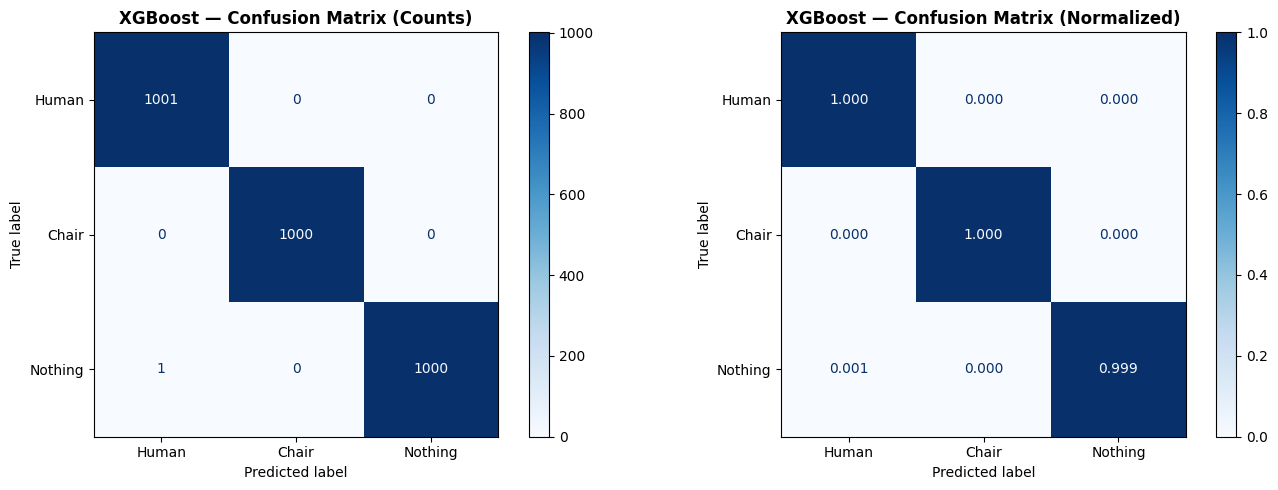


Per-Class Accuracy:
  Human     : 100.00%
  Chair     : 100.00%
  Nothing   : 99.90%


In [ ]:
best = results[best_name]

print(f'\n{"="*65}')
print(f'  DETAILED RESULTS — {best_name}')
print(f'{"="*65}')

# Classification report
print(f'\nClassification Report:')
print(classification_report(y_test, best['y_pred'], target_names=label_names))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'{best_name} — Confusion Matrix (Counts)', fontweight='bold')

# Normalized (percentages)
cm_norm = confusion_matrix(y_test, best['y_pred'], normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=label_names)
disp2.plot(ax=axes[1], cmap='Blues', values_format='.3f')
axes[1].set_title(f'{best_name} — Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/step2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print(f'\nPer-Class Accuracy:')
for i, name in enumerate(label_names):
    class_acc = cm_norm[i, i]
    print(f'  {name:10s}: {class_acc*100:.2f}%')

## Cell 11 — Feature Importance (What matters most?)

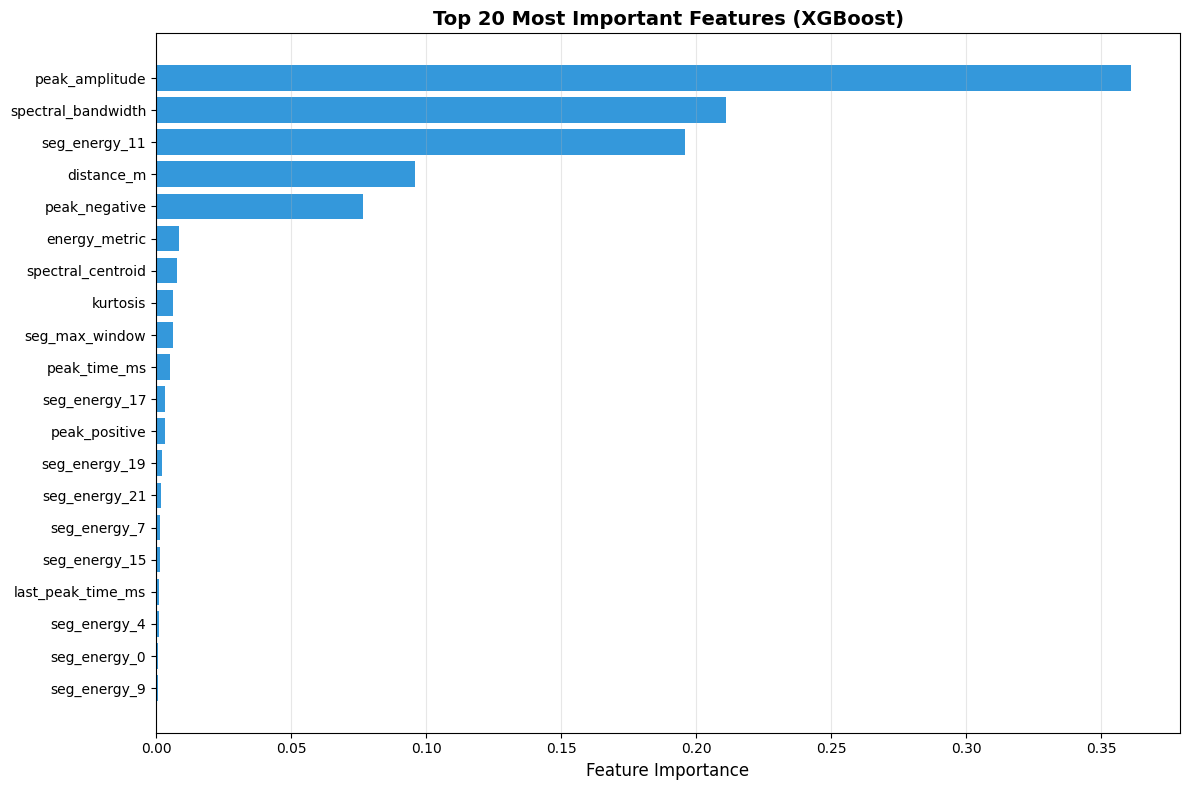


Top 10 most important features:
   1. peak_amplitude            importance=0.3612
   2. spectral_bandwidth        importance=0.2111
   3. seg_energy_11             importance=0.1958
   4. distance_m                importance=0.0959
   5. peak_negative             importance=0.0766
   6. energy_metric             importance=0.0083
   7. spectral_centroid         importance=0.0076
   8. kurtosis                  importance=0.0062
   9. seg_max_window            importance=0.0061
  10. peak_time_ms              importance=0.0050


In [ ]:
# Get feature importance from tree-based models
# Use the best tree-based model
tree_models = ['Random Forest', 'XGBoost', 'LightGBM']
best_tree = max(tree_models, key=lambda x: results[x]['accuracy'])
tree_model = results[best_tree]['model']

feature_names = X_df.columns.tolist()
importances = tree_model.feature_importances_

# Sort by importance
sorted_idx = np.argsort(importances)[::-1]

# Plot top 20 features
top_n = 20
fig, ax = plt.subplots(figsize=(12, 8))

top_idx = sorted_idx[:top_n]
ax.barh(range(top_n), importances[top_idx][::-1], color='#3498db')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in top_idx][::-1])
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features ({best_tree})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/step2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 10 most important features:')
for rank, idx in enumerate(sorted_idx[:10]):
    print(f'  {rank+1:2d}. {feature_names[idx]:<25s} importance={importances[idx]:.4f}')

## Cell 12 — Save the Best Model
Saves the model + scaler + feature names so that can used later for real-time prediction.

In [ ]:
# Save to Google Drive
SAVE_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(SAVE_DIR, exist_ok=True)

save_data = {
    'model': best['model'],
    'model_name': best_name,
    'scaler': scaler,
    'needs_scaling': best['needs_scaling'],
    'feature_names': feature_names,
    'label_names': label_names,
    'accuracy': best['accuracy'],
    'all_results': {k: {'accuracy': v['accuracy'], 'train_time': v['train_time']}
                   for k, v in results.items()},
}

save_path = os.path.join(SAVE_DIR, 'best_model.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f'✅ Best model saved to: {save_path}')
print(f'   Model: {best_name}')
print(f'   Accuracy: {best["accuracy"]*100:.2f}%')
print(f'   File size: {os.path.getsize(save_path)/1e6:.1f} MB')

✅ Best model saved to: /content/drive/MyDrive/VER Machine Learning Data/models/best_model.pkl
   Model: XGBoost
   Accuracy: 99.97%
   File size: 0.6 MB


## Cell 13 — Final Summary Report

In [ ]:
print('='*65)
print('     STEP 2 — FINAL SUMMARY REPORT')
print('='*65)

print(f'\nDATA:')
print(f'  Total samples: {len(y)}')
print(f'  Features extracted: {X_df.shape[1]}')
print(f'  Train/Test split: {len(y_train)}/{len(y_test)}')

print(f'\nALL MODEL RESULTS:')
for name, r in sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    marker = '🏆' if name == best_name else '  '
    print(f'  {marker} {name:<25s}: {r["accuracy"]*100:.2f}%')

print(f'\nBEST MODEL: {best_name}')
print(f'  Accuracy: {best["accuracy"]*100:.2f}%')
print(f'  Train time: {best["train_time"]:.1f}s')
print(f'  Predict time ({len(y_test)} samples): {best["predict_time"]:.3f}s')
print(f'  Predict time per sample: {best["predict_time"]/len(y_test)*1000:.2f}ms')

print(f'\nPER-CLASS RESULTS ({best_name}):')
cm_norm = confusion_matrix(y_test, best['y_pred'], normalize='true')
for i, name in enumerate(label_names):
    print(f'  {name:10s}: {cm_norm[i,i]*100:.2f}% accuracy')

target_met = best['accuracy'] >= 0.95
print(f'\n{"="*65}')
if target_met:
    print(f'  ✅ TARGET MET! Accuracy ≥ 95% achieved!')
else:
    print(f'  ⚠️  TARGET NOT YET MET (need ≥ 95%)')
print(f'{'='*65}')

     STEP 2 — FINAL SUMMARY REPORT

DATA:
  Total samples: 15007
  Features extracted: 52
  Train/Test split: 12005/3002

ALL MODEL RESULTS:
  🏆 XGBoost                  : 99.97%
     LightGBM                 : 99.97%
     Random Forest            : 99.93%
     KNN (k=5)                : 99.90%
     SVM (RBF)                : 99.83%
     Logistic Regression      : 99.67%

BEST MODEL: XGBoost
  Accuracy: 99.97%
  Train time: 1.8s
  Predict time (3002 samples): 0.019s
  Predict time per sample: 0.01ms

PER-CLASS RESULTS (XGBoost):
  Human     : 100.00% accuracy
  Chair     : 100.00% accuracy
  Nothing   : 99.90% accuracy

  ✅ TARGET MET! Accuracy ≥ 95% achieved!
  → Next: Share this report and we proceed to model optimization
